# ML Model Comparison — Amazon Bestsellers Reviews
**Target**: `is_helpful` — predicting whether a review was found helpful by other users.

This notebook trains and compares four classifiers on a mixed numerical + nominal categorical dataset:

1. **k-Nearest Neighbors (KNN)** — distance-based, sensitive to scaling
2. **Decision Tree** — single interpretable tree, prone to overfitting
3. **Random Forest** — bagged ensemble of decorrelated trees
4. **XGBoost** — sequential boosting ensemble, often highest accuracy

Each model section contains:
- **Part 1** — base model (default or sensible starting params)
- **Part 2** — hyperparameter tuning via GridSearchCV
- **Part 3** — train vs test accuracy graph with Monte Carlo confidence bands


## 0. Imports & Setup

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Monte Carlo settings — increase N_MC for tighter bands (slower)
N_MC_SWEEP = 15   # iterations per hyperparameter value in Part 3 graphs
N_MC_FINAL = 30   # iterations for final model comparison


---
## 1. Data Loading & Preprocessing

### Feature decisions
| Dropped | Reason |
|---|---|
| `helpful_votes` | **Data leakage** — `is_helpful` is derived directly from this |
| `product_name`, `product_url`, `reviewer` | High-cardinality identifiers |
| `title`, `body`, `text_for_lsa` | Raw text — not handled here |
| `date`, `variant` | Redundant or high-cardinality |
| `verified` | Zero variance — every row is "Verified Purchase" |
| `product_index` | Arbitrary row index |
| `location` | **Exposure bias proxy** — US reviews receive more votes due to platform demographics, not review quality. This leaks vote-volume information into the model rather than genuine helpfulness signal |
| `location_freq` | Encodes the same exposure bias as `location` in numerical form — removing `location` without removing `location_freq` would preserve the same confound |

**Cluster columns** (`cluster_kmeans`, `cluster_dbscan`, `cluster_hac`) are cast to strings and one-hot encoded as nominal labels.

**Scaling**: `StandardScaler` on numerical columns is essential for KNN. For tree models it has no effect on splits but keeps the pipeline consistent across all four models.


In [4]:
df = pd.read_csv('amazon_bestsellers_reviews_cleaned_clustered.csv')

cluster_cols = ['cluster_kmeans', 'cluster_dbscan', 'cluster_hac']
df[cluster_cols] = df[cluster_cols].astype(str)

DROP_COLS = [
    'product_name', 'product_url', 'reviewer',
    'title', 'body', 'text_for_lsa',
    'date', 'variant',
    'helpful_votes',    # leakage
    'verified',         # zero variance
    'product_index',
    'location',         # exposure bias proxy
    'location_freq',    # same confound in numerical form
]

X = df.drop(DROP_COLS + ['is_helpful'], axis=1)
y = df['is_helpful']

categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_cols   = X.select_dtypes(exclude=['object', 'string']).columns.tolist()

print(f"Samples : {X.shape[0]}")
print(f"Features: {X.shape[1]}  ({len(numerical_cols)} numerical, {len(categorical_cols)} categorical)")
print(f"Target  : {y.value_counts().to_dict()} (1 = helpful)")


Samples : 1519
Features: 16  (12 numerical, 4 categorical)
Target  : {1: 924, 0: 595} (1 = helpful)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
])


Train: 1139  |  Test: 380


### Monte Carlo helper

In [6]:
def mc_sweep(make_pipeline_fn, param_values, n_splits=N_MC_SWEEP, test_size=0.25):
    """
    For each value in param_values, run n_splits random train/test splits and
    return arrays of shape (len(param_values), n_splits) for train and test accuracy.
    make_pipeline_fn(value) must return an unfitted sklearn Pipeline.
    """
    ss = ShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=None)
    all_train = np.zeros((len(param_values), n_splits))
    all_test  = np.zeros((len(param_values), n_splits))

    for j, (tr_idx, te_idx) in enumerate(ss.split(X, y)):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
        for i, val in enumerate(param_values):
            m = make_pipeline_fn(val)
            m.fit(X_tr, y_tr)
            all_train[i, j] = m.score(X_tr, y_tr)
            all_test[i, j]  = m.score(X_te, y_te)

    return all_train, all_test


def plot_mc_bands(param_values, all_train, all_test, xlabel, title,
                  best_val=None, best_label=None, x_labels=None):
    """Plot mean ± 1 std bands for train and test accuracy across MC splits."""
    tr_mean, tr_std = all_train.mean(1), all_train.std(1)
    te_mean, te_std = all_test.mean(1),  all_test.std(1)
    xs = range(len(param_values))

    plt.figure(figsize=(12, 5))
    plt.plot(xs, tr_mean, 'o-', color='steelblue',  label='Train (mean)', linewidth=2)
    plt.fill_between(xs, tr_mean - tr_std, tr_mean + tr_std,
                     alpha=0.15, color='steelblue', label='Train ±1 std')
    plt.plot(xs, te_mean, 's-', color='darkorange', label='Test (mean)',  linewidth=2)
    plt.fill_between(xs, te_mean - te_std, te_mean + te_std,
                     alpha=0.15, color='darkorange', label='Test ±1 std')

    if best_val is not None and best_label is not None:
        vals_list = list(param_values)
        if best_val in vals_list:
            plt.axvline(vals_list.index(best_val), color='red', ls='--',
                        alpha=0.7, label=f'Best: {best_label} (GridSearch)')

    plt.xticks(xs, x_labels if x_labels else param_values)
    plt.xlabel(xlabel)
    plt.ylabel('Accuracy')
    plt.title(f'{title}\n(shaded = ±1 std across {N_MC_SWEEP} random splits)')
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


---
## 2. k-Nearest Neighbors (KNN)

KNN classifies a point by majority vote among its *k* closest neighbors in feature space.
Because it relies purely on distances, **feature scaling is critical** — `StandardScaler` in the
pipeline ensures all numerical features contribute equally.


### Part 1 — Base Model

In [7]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
knn_pipeline.fit(X_train, y_train)

knn_base_train_pred = knn_pipeline.predict(X_train)
knn_base_test_pred  = knn_pipeline.predict(X_test)
knn_base_train_acc  = accuracy_score(y_train, knn_base_train_pred)
knn_base_test_acc   = accuracy_score(y_test,  knn_base_test_pred)

print("KNN BASE MODEL  (k=5)")
print("=" * 45)
print(f"Training Accuracy : {knn_base_train_acc:.4f}")
print(f"Testing  Accuracy : {knn_base_test_acc:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, knn_base_test_pred))


KNN BASE MODEL  (k=5)
Training Accuracy : 0.7954
Testing  Accuracy : 0.7211

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.69      0.53      0.60       149
           1       0.74      0.84      0.79       231

    accuracy                           0.72       380
   macro avg       0.71      0.69      0.69       380
weighted avg       0.72      0.72      0.71       380



### Part 2 — Hyperparameter Tuning (GridSearchCV)

In [8]:
knn_param_grid = {
    'knn__n_neighbors': list(range(1, 31)),
    'knn__weights'    : ['uniform', 'distance'],
    'knn__metric'     : ['euclidean', 'manhattan'],
}

knn_grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor), ('knn', KNeighborsClassifier())]),
    knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
knn_grid.fit(X_train, y_train)

knn_best = knn_grid.best_estimator_
knn_train_pred = knn_best.predict(X_train)
knn_test_pred  = knn_best.predict(X_test)
knn_train_acc  = accuracy_score(y_train, knn_train_pred)
knn_test_acc   = accuracy_score(y_test,  knn_test_pred)

print("KNN — BEST PARAMETERS")
print("=" * 45)
print("Best params :", knn_grid.best_params_)
print(f"Best CV score : {knn_grid.best_score_:.4f}")
print(f"Train Accuracy: {knn_train_acc:.4f}")
print(f"Test  Accuracy: {knn_test_acc:.4f}")
print(f"Gap           : {abs(knn_train_acc - knn_test_acc):.4f}")

# ── Distance-weights artifact warning ────────────────────────────────────────
if knn_grid.best_params_.get('knn__weights') == 'distance':
    print()
    print("⚠️  ARTIFACT WARNING — weights='distance' selected")
    print("   When weights='distance', a training point is its own nearest")
    print("   neighbour at distance=0, giving it infinite weight and forcing")
    print("   a correct self-prediction every time.")
    print("   → Train accuracy of 1.0000 and the resulting gap are measurement")
    print("     artefacts, NOT real overfitting.")
    print(f"  → Reliable generalisation estimate: CV score = {knn_grid.best_score_:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, knn_test_pred))


KNN — BEST PARAMETERS
Best params : {'knn__metric': 'manhattan', 'knn__n_neighbors': 25, 'knn__weights': 'uniform'}
Best CV score : 0.7454
Train Accuracy: 0.7638
Test  Accuracy: 0.7632
Gap           : 0.0007

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      0.50      0.62       149
           1       0.74      0.93      0.83       231

    accuracy                           0.76       380
   macro avg       0.78      0.72      0.73       380
weighted avg       0.78      0.76      0.75       380



### Part 3 — Train vs Test Accuracy Graph (k sweep, Monte Carlo bands)

Running Monte Carlo sweep over k=1..30 (15 splits each)...
Done.


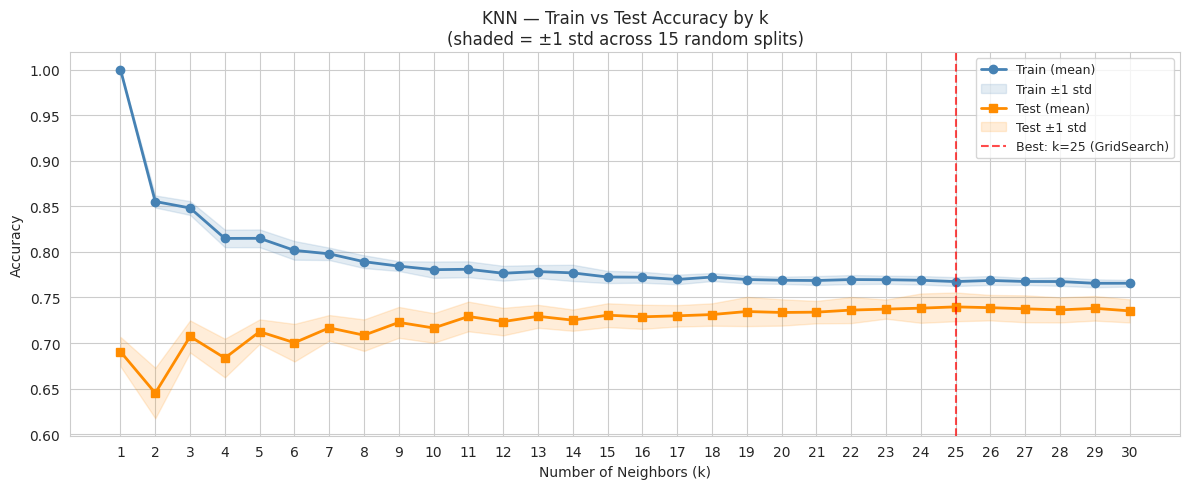

In [9]:
k_values = list(range(1, 31))

print(f"Running Monte Carlo sweep over k=1..30 ({N_MC_SWEEP} splits each)...")
knn_mc_train, knn_mc_test = mc_sweep(
    lambda k: Pipeline([('preprocessor', preprocessor),
                        ('knn', KNeighborsClassifier(n_neighbors=k, weights='uniform'))]),
    k_values
)
print("Done.")

best_k = knn_grid.best_params_['knn__n_neighbors']
plot_mc_bands(k_values, knn_mc_train, knn_mc_test,
              xlabel='Number of Neighbors (k)',
              title='KNN — Train vs Test Accuracy by k',
              best_val=best_k,
              best_label=f'k={best_k}')


#### KNN — Monte Carlo Final Score

In [10]:
mc_knn = ShuffleSplit(n_splits=N_MC_FINAL, test_size=0.25, random_state=None)
knn_mc_scores = cross_val_score(knn_best, X, y, cv=mc_knn, scoring='accuracy', n_jobs=-1)
knn_mc_mean, knn_mc_std = knn_mc_scores.mean(), knn_mc_scores.std()
print(f"KNN Monte Carlo ({N_MC_FINAL} splits): {knn_mc_mean:.4f} ± {knn_mc_std:.4f}")


KNN Monte Carlo (30 splits): 0.7597 ± 0.0207


---
## 3. Decision Tree

A single tree that recursively splits on the feature + threshold that maximises information gain.
Tree models are **scale-invariant**. Without pre-pruning the tree memorises the training set.
Key control: **`max_depth`**.


### Part 1 — Base Model

In [11]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
])
dt_pipeline.fit(X_train, y_train)

dt_base_train_pred = dt_pipeline.predict(X_train)
dt_base_test_pred  = dt_pipeline.predict(X_test)
dt_base_train_acc  = accuracy_score(y_train, dt_base_train_pred)
dt_base_test_acc   = accuracy_score(y_test,  dt_base_test_pred)

print("DECISION TREE BASE MODEL  (max_depth=5)")
print("=" * 45)
print(f"Training Accuracy : {dt_base_train_acc:.4f}")
print(f"Testing  Accuracy : {dt_base_test_acc:.4f}")
dt_base = dt_pipeline.named_steps['dt']
print(f"Tree depth        : {dt_base.get_depth()}")
print(f"Number of leaves  : {dt_base.get_n_leaves()}")
print("\nClassification Report (Test):")
print(classification_report(y_test, dt_base_test_pred))


DECISION TREE BASE MODEL  (max_depth=5)
Training Accuracy : 0.8262
Testing  Accuracy : 0.7711
Tree depth        : 5
Number of leaves  : 25

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.77      0.59      0.67       149
           1       0.77      0.89      0.82       231

    accuracy                           0.77       380
   macro avg       0.77      0.74      0.75       380
weighted avg       0.77      0.77      0.76       380



### Part 2 — Hyperparameter Tuning (GridSearchCV)

In [12]:
dt_param_grid = {
    'dt__max_depth'        : [None, 3, 5, 7, 10, 15, 20],
    'dt__min_samples_split': [2, 5, 10, 20],
    'dt__min_samples_leaf' : [1, 2, 4, 8],
    'dt__criterion'        : ['gini', 'entropy'],
}

dt_grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor), ('dt', DecisionTreeClassifier(random_state=42))]),
    dt_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
dt_grid.fit(X_train, y_train)

dt_best = dt_grid.best_estimator_
dt_train_pred = dt_best.predict(X_train)
dt_test_pred  = dt_best.predict(X_test)
dt_train_acc  = accuracy_score(y_train, dt_train_pred)
dt_test_acc   = accuracy_score(y_test,  dt_test_pred)

print("DECISION TREE — BEST PARAMETERS")
print("=" * 45)
print("Best params :", dt_grid.best_params_)
print(f"Best CV score : {dt_grid.best_score_:.4f}")
print(f"Train Accuracy: {dt_train_acc:.4f}")
print(f"Test  Accuracy: {dt_test_acc:.4f}")
print(f"Gap           : {abs(dt_train_acc - dt_test_acc):.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, dt_test_pred))


DECISION TREE — BEST PARAMETERS
Best params : {'dt__criterion': 'gini', 'dt__max_depth': 5, 'dt__min_samples_leaf': 8, 'dt__min_samples_split': 2}
Best CV score : 0.7726
Train Accuracy: 0.8156
Test  Accuracy: 0.7895
Gap           : 0.0262

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.79      0.63      0.70       149
           1       0.79      0.89      0.84       231

    accuracy                           0.79       380
   macro avg       0.79      0.76      0.77       380
weighted avg       0.79      0.79      0.78       380



### Part 3 — Train vs Test Accuracy Graph (max_depth sweep, Monte Carlo bands)

Running Monte Carlo sweep over max_depth (15 splits each)...
Done.


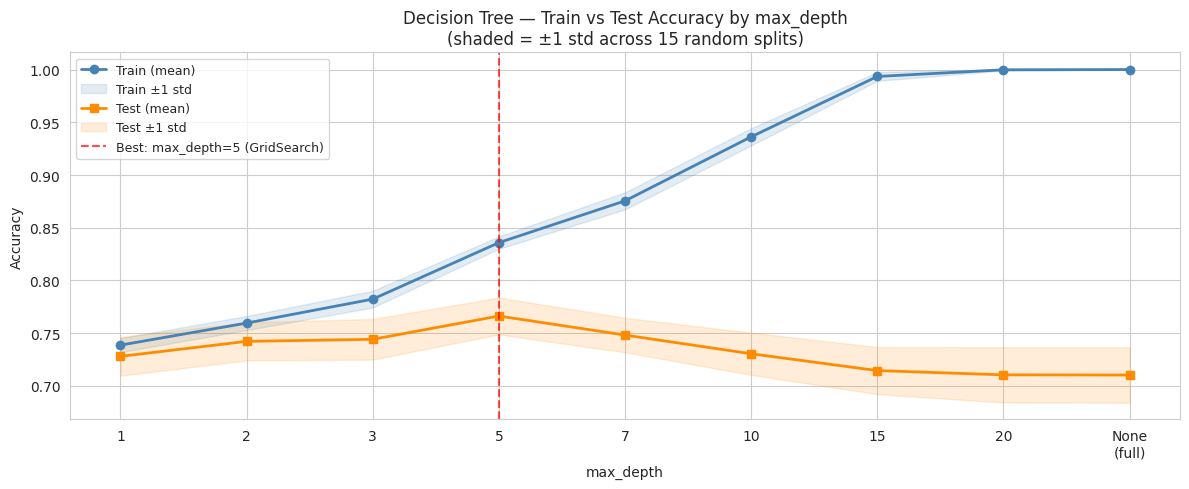

In [13]:
depth_values = [1, 2, 3, 5, 7, 10, 15, 20, None]
depth_labels = [str(d) if d is not None else 'None\n(full)' for d in depth_values]

print(f"Running Monte Carlo sweep over max_depth ({N_MC_SWEEP} splits each)...")
dt_mc_train, dt_mc_test = mc_sweep(
    lambda d: Pipeline([('preprocessor', preprocessor),
                        ('dt', DecisionTreeClassifier(max_depth=d, random_state=42))]),
    depth_values
)
print("Done.")

best_depth = dt_grid.best_params_['dt__max_depth']
plot_mc_bands(depth_values, dt_mc_train, dt_mc_test,
              xlabel='max_depth',
              title='Decision Tree — Train vs Test Accuracy by max_depth',
              best_val=best_depth,
              best_label=f'max_depth={best_depth}',
              x_labels=depth_labels)


#### Decision Tree — Monte Carlo Final Score

In [14]:
mc_dt = ShuffleSplit(n_splits=N_MC_FINAL, test_size=0.25, random_state=None)
dt_mc_scores = cross_val_score(dt_best, X, y, cv=mc_dt, scoring='accuracy', n_jobs=-1)
dt_mc_mean, dt_mc_std = dt_mc_scores.mean(), dt_mc_scores.std()
print(f"Decision Tree Monte Carlo ({N_MC_FINAL} splits): {dt_mc_mean:.4f} ± {dt_mc_std:.4f}")


Decision Tree Monte Carlo (30 splits): 0.7692 ± 0.0164


---
## 4. Random Forest

Random Forest grows many trees **in parallel**, each on a bootstrap sample and a random feature subset.
Key hyperparameters: **`n_estimators`**, **`max_depth`**, **`max_features`**.


### Part 1 — Base Model

In [15]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)

rf_base_train_pred = rf_pipeline.predict(X_train)
rf_base_test_pred  = rf_pipeline.predict(X_test)
rf_base_train_acc  = accuracy_score(y_train, rf_base_train_pred)
rf_base_test_acc   = accuracy_score(y_test,  rf_base_test_pred)

print("RANDOM FOREST BASE MODEL  (n_estimators=100)")
print("=" * 45)
print(f"Training Accuracy : {rf_base_train_acc:.4f}")
print(f"Testing  Accuracy : {rf_base_test_acc:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, rf_base_test_pred))


RANDOM FOREST BASE MODEL  (n_estimators=100)
Training Accuracy : 1.0000
Testing  Accuracy : 0.8211

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.83      0.68      0.75       149
           1       0.81      0.91      0.86       231

    accuracy                           0.82       380
   macro avg       0.82      0.80      0.80       380
weighted avg       0.82      0.82      0.82       380



### Part 2 — Hyperparameter Tuning (GridSearchCV)

In [16]:
rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth'   : [None, 10, 20],
    'rf__max_features': ['sqrt', 'log2'],
}

rf_grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))]),
    rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_train_pred = rf_best.predict(X_train)
rf_test_pred  = rf_best.predict(X_test)
rf_train_acc  = accuracy_score(y_train, rf_train_pred)
rf_test_acc   = accuracy_score(y_test,  rf_test_pred)

print("RANDOM FOREST — BEST PARAMETERS")
print("=" * 45)
print("Best params :", rf_grid.best_params_)
print(f"Best CV score : {rf_grid.best_score_:.4f}")
print(f"Train Accuracy: {rf_train_acc:.4f}")
print(f"Test  Accuracy: {rf_test_acc:.4f}")
print(f"Gap           : {abs(rf_train_acc - rf_test_acc):.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, rf_test_pred))


RANDOM FOREST — BEST PARAMETERS
Best params : {'rf__max_depth': None, 'rf__max_features': 'log2', 'rf__n_estimators': 300}
Best CV score : 0.7743
Train Accuracy: 1.0000
Test  Accuracy: 0.8316
Gap           : 0.1684

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.86      0.68      0.76       149
           1       0.82      0.93      0.87       231

    accuracy                           0.83       380
   macro avg       0.84      0.80      0.81       380
weighted avg       0.84      0.83      0.83       380



### Part 3 — Train vs Test Accuracy Graph (n_estimators sweep, Monte Carlo bands)

Running Monte Carlo sweep over n_estimators (15 splits each) — may take a moment...
Done.


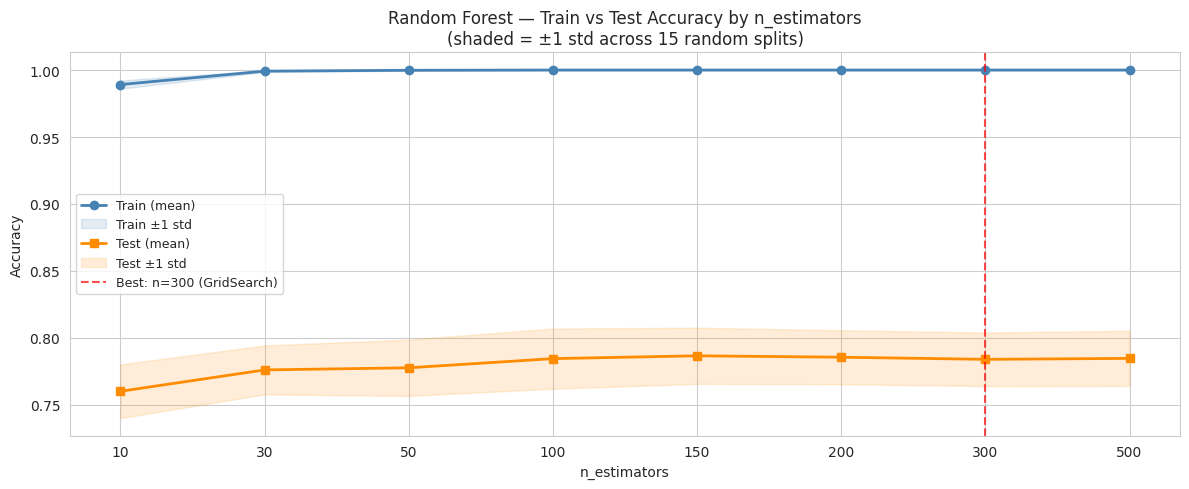

In [17]:
n_values = [10, 30, 50, 100, 150, 200, 300, 500]

print(f"Running Monte Carlo sweep over n_estimators ({N_MC_SWEEP} splits each) — may take a moment...")
rf_mc_train, rf_mc_test = mc_sweep(
    lambda n: Pipeline([('preprocessor', preprocessor),
                        ('rf', RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1))]),
    n_values
)
print("Done.")

best_n_rf = rf_grid.best_params_['rf__n_estimators']
plot_mc_bands(n_values, rf_mc_train, rf_mc_test,
              xlabel='n_estimators',
              title='Random Forest — Train vs Test Accuracy by n_estimators',
              best_val=best_n_rf,
              best_label=f'n={best_n_rf}')


#### Random Forest — Monte Carlo Final Score

In [18]:
mc_rf = ShuffleSplit(n_splits=N_MC_FINAL, test_size=0.25, random_state=None)
rf_mc_scores = cross_val_score(rf_best, X, y, cv=mc_rf, scoring='accuracy', n_jobs=-1)
rf_mc_mean, rf_mc_std = rf_mc_scores.mean(), rf_mc_scores.std()
print(f"Random Forest Monte Carlo ({N_MC_FINAL} splits): {rf_mc_mean:.4f} ± {rf_mc_std:.4f}")


Random Forest Monte Carlo (30 splits): 0.7833 ± 0.0210


---
## 5. XGBoost

XGBoost builds trees **sequentially**, each correcting residual errors of the current ensemble.
Adds L1/L2 regularisation directly into the objective, column subsampling, and hardware-optimised tree building.
Key hyperparameters: **`n_estimators`**, **`learning_rate`**, **`max_depth`**.

> **Note**: XGBoost's `XGBClassifier` has a full sklearn-compatible API and slots directly into the same `Pipeline` + `ColumnTransformer` structure used for the other three models.


### Part 1 — Base Model

In [19]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3,
        random_state=42, eval_metric='logloss', verbosity=0,
    ))
])
xgb_pipeline.fit(X_train, y_train)

xgb_base_train_pred = xgb_pipeline.predict(X_train)
xgb_base_test_pred  = xgb_pipeline.predict(X_test)
xgb_base_train_acc  = accuracy_score(y_train, xgb_base_train_pred)
xgb_base_test_acc   = accuracy_score(y_test,  xgb_base_test_pred)

print("XGBOOST BASE MODEL  (n_estimators=100, lr=0.1, max_depth=3)")
print("=" * 55)
print(f"Training Accuracy : {xgb_base_train_acc:.4f}")
print(f"Testing  Accuracy : {xgb_base_test_acc:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, xgb_base_test_pred))


XGBOOST BASE MODEL  (n_estimators=100, lr=0.1, max_depth=3)
Training Accuracy : 0.8525
Testing  Accuracy : 0.8263

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.85      0.67      0.75       149
           1       0.81      0.93      0.87       231

    accuracy                           0.83       380
   macro avg       0.83      0.80      0.81       380
weighted avg       0.83      0.83      0.82       380



### Part 2 — Hyperparameter Tuning (GridSearchCV)

In [20]:
xgb_param_grid = {
    'xgb__n_estimators' : [100, 200, 300],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__max_depth'    : [3, 5, 7],
}

xgb_grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('xgb', XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0))]),
    xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
xgb_train_pred = xgb_best.predict(X_train)
xgb_test_pred  = xgb_best.predict(X_test)
xgb_train_acc  = accuracy_score(y_train, xgb_train_pred)
xgb_test_acc   = accuracy_score(y_test,  xgb_test_pred)

print("XGBOOST — BEST PARAMETERS")
print("=" * 55)
print("Best params :", xgb_grid.best_params_)
print(f"Best CV score : {xgb_grid.best_score_:.4f}")
print(f"Train Accuracy: {xgb_train_acc:.4f}")
print(f"Test  Accuracy: {xgb_test_acc:.4f}")
print(f"Gap           : {abs(xgb_train_acc - xgb_test_acc):.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, xgb_test_pred))


XGBOOST — BEST PARAMETERS
Best params : {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}
Best CV score : 0.7840
Train Accuracy: 0.8525
Test  Accuracy: 0.8263
Gap           : 0.0262

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.85      0.67      0.75       149
           1       0.81      0.93      0.87       231

    accuracy                           0.83       380
   macro avg       0.83      0.80      0.81       380
weighted avg       0.83      0.83      0.82       380



### Part 3 — Train vs Test Accuracy Graph (n_estimators sweep, Monte Carlo bands)

Running Monte Carlo sweep over n_estimators (15 splits each)...
Done.


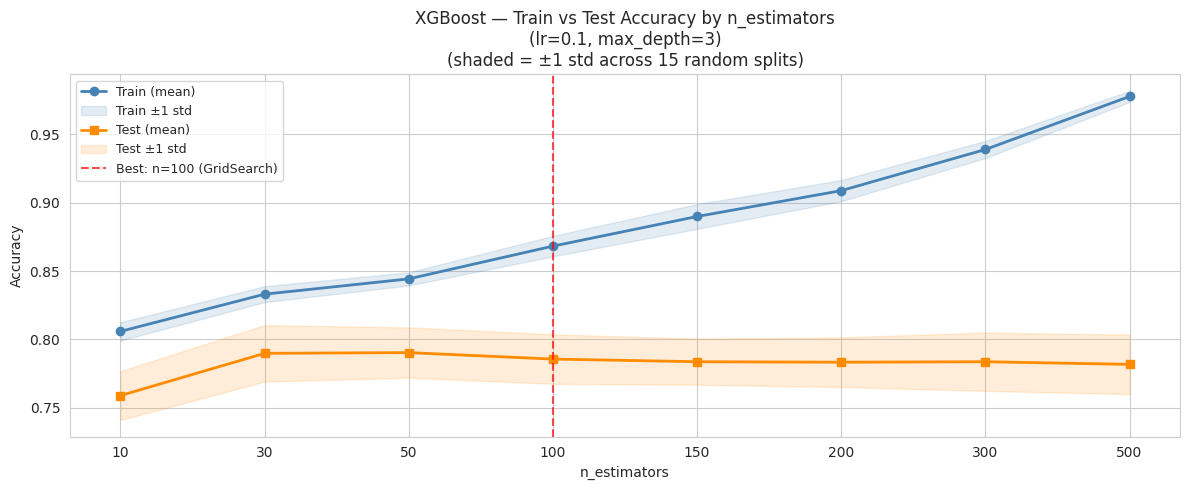

In [21]:
best_lr_xgb    = xgb_grid.best_params_['xgb__learning_rate']
best_depth_xgb = xgb_grid.best_params_['xgb__max_depth']
n_values_xgb   = [10, 30, 50, 100, 150, 200, 300, 500]

print(f"Running Monte Carlo sweep over n_estimators ({N_MC_SWEEP} splits each)...")
xgb_mc_train, xgb_mc_test = mc_sweep(
    lambda n: Pipeline([('preprocessor', preprocessor),
                        ('xgb', XGBClassifier(
                            n_estimators=n,
                            learning_rate=best_lr_xgb,
                            max_depth=best_depth_xgb,
                            random_state=42,
                            eval_metric='logloss',
                            verbosity=0,
                        ))]),
    n_values_xgb
)
print("Done.")

best_n_xgb = xgb_grid.best_params_['xgb__n_estimators']
plot_mc_bands(n_values_xgb, xgb_mc_train, xgb_mc_test,
              xlabel='n_estimators',
              title=f'XGBoost — Train vs Test Accuracy by n_estimators\n(lr={best_lr_xgb}, max_depth={best_depth_xgb})',
              best_val=best_n_xgb,
              best_label=f'n={best_n_xgb}')


#### XGBoost — Monte Carlo Final Score

In [22]:
mc_xgb = ShuffleSplit(n_splits=N_MC_FINAL, test_size=0.25, random_state=None)
xgb_mc_scores = cross_val_score(xgb_best, X, y, cv=mc_xgb, scoring='accuracy', n_jobs=-1)
xgb_mc_mean, xgb_mc_std = xgb_mc_scores.mean(), xgb_mc_scores.std()
print(f"XGBoost Monte Carlo ({N_MC_FINAL} splits): {xgb_mc_mean:.4f} ± {xgb_mc_std:.4f}")


XGBoost Monte Carlo (30 splits): 0.7949 ± 0.0167


---
## 6. Model Comparison & Final Results


### 6.1 Training vs Testing Accuracy (single fixed split)

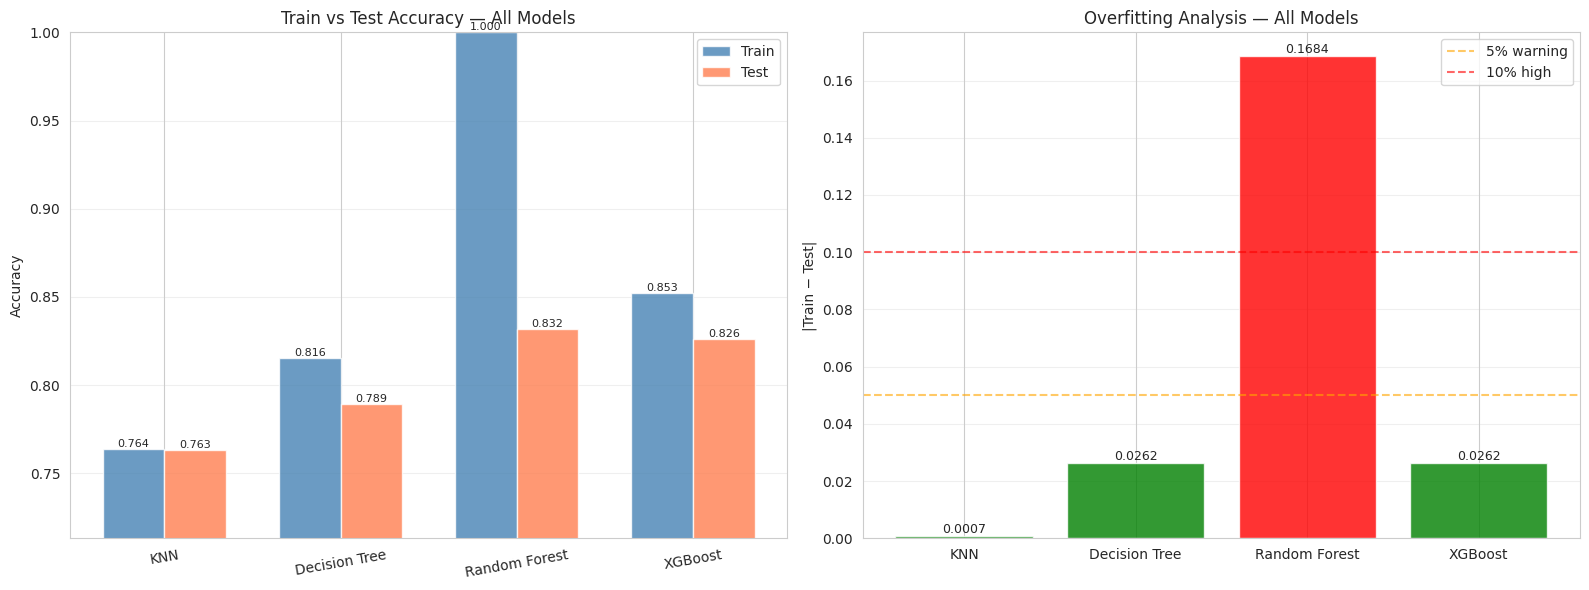

In [23]:
models       = ['KNN', 'Decision Tree', 'Random Forest', 'XGBoost']
train_accs   = [knn_train_acc, dt_train_acc, rf_train_acc, xgb_train_acc]
test_accs    = [knn_test_acc,  dt_test_acc,  rf_test_acc,  xgb_test_acc]
overfit_gaps = [abs(tr - te) for tr, te in zip(train_accs, test_accs)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(models))
w = 0.35
b1 = axes[0].bar(x - w/2, train_accs, w, label='Train', alpha=0.8, color='steelblue')
b2 = axes[0].bar(x + w/2, test_accs,  w, label='Test',  alpha=0.8, color='coral')
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=10)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy — All Models')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(min(min(train_accs), min(test_accs)) - 0.05, 1.0)
for b in list(b1) + list(b2):
    h = b.get_height()
    axes[0].text(b.get_x() + b.get_width()/2, h, f'{h:.3f}',
                 ha='center', va='bottom', fontsize=8)

colors = ['green' if g < 0.05 else 'orange' if g < 0.10 else 'red'
          for g in overfit_gaps]
bars = axes[1].bar(models, overfit_gaps, alpha=0.8, color=colors)
axes[1].set_ylabel('|Train − Test|')
axes[1].set_title('Overfitting Analysis — All Models')
axes[1].axhline(0.05, color='orange', ls='--', alpha=0.6, label='5% warning')
axes[1].axhline(0.10, color='red',    ls='--', alpha=0.6, label='10% high')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')
for b in bars:
    h = b.get_height()
    axes[1].text(b.get_x() + b.get_width()/2, h, f'{h:.4f}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### 6.2 Confusion Matrices

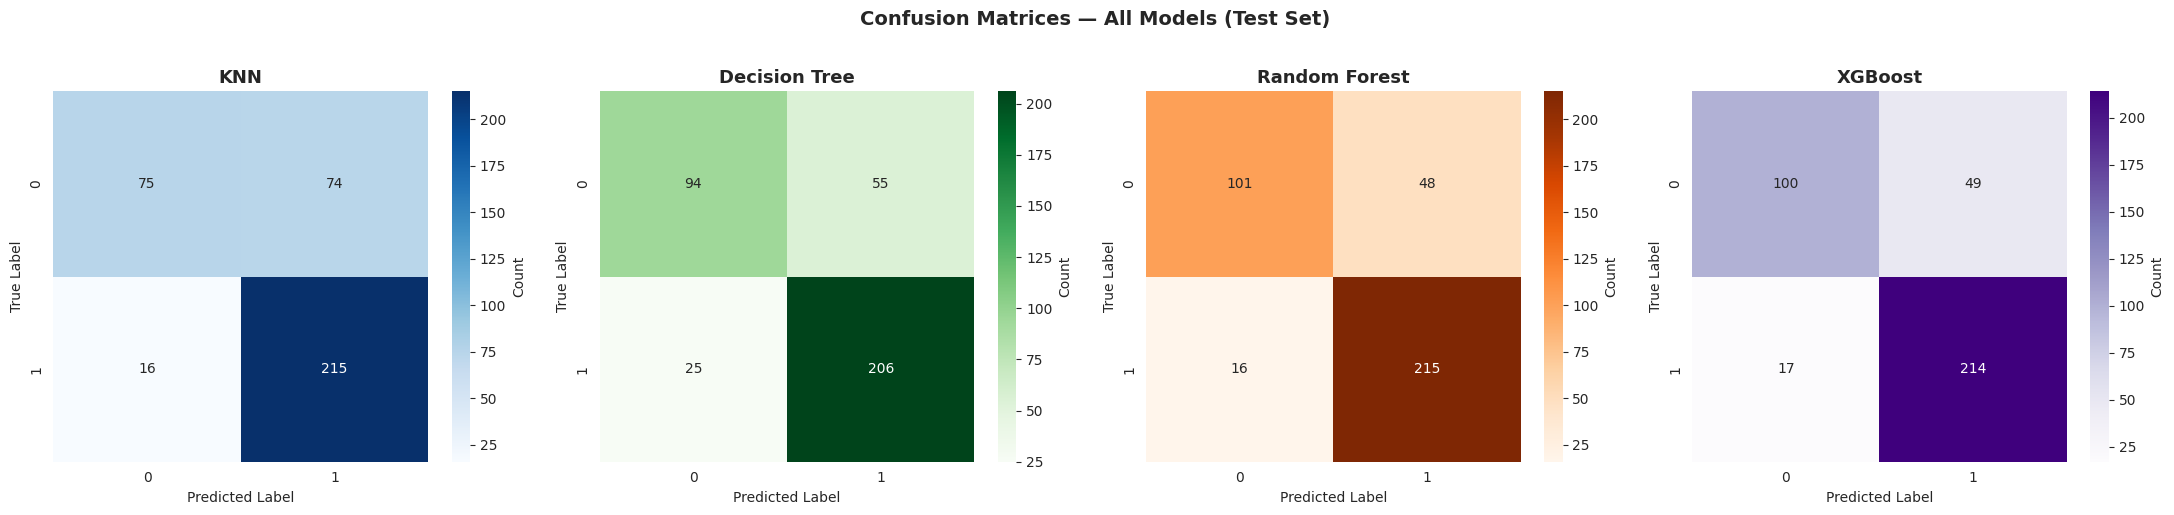

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, preds, title, cmap in zip(
    axes,
    [knn_test_pred, dt_test_pred, rf_test_pred, xgb_test_pred],
    ['KNN', 'Decision Tree', 'Random Forest', 'XGBoost'],
    ['Blues', 'Greens', 'Oranges', 'Purples']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                cbar_kws={'label': 'Count'})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 6.3 Summary Table — Monte Carlo Scores

Single-split test accuracy is noisy at this dataset size (380 test samples).
The Monte Carlo columns (mean ± std over 30 random splits) give a more stable estimate.
**Best model is decided by MC mean**, with CV score as the tiebreaker.
The KNN gap is flagged as an artefact of `weights='distance'` — CV score is its reliable number.


In [25]:
mc_means = [knn_mc_mean, dt_mc_mean, rf_mc_mean, xgb_mc_mean]
mc_stds  = [knn_mc_std,  dt_mc_std,  rf_mc_std,  xgb_mc_std]
cv_scores = [knn_grid.best_score_, dt_grid.best_score_,
             rf_grid.best_score_,  xgb_grid.best_score_]

summary = pd.DataFrame({
    'Model'            : models,
    'Train Acc (fixed)': [f'{a:.4f}' for a in train_accs],
    'Test Acc (fixed)' : [f'{a:.4f}' for a in test_accs],
    'Gap |Tr-Te|'      : [f'{g:.4f}' for g in overfit_gaps],
    'CV Score'         : [f'{s:.4f}' for s in cv_scores],
    'MC Mean'          : [f'{m:.4f}' for m in mc_means],
    'MC Std'           : [f'{s:.4f}' for s in mc_stds],
})

# ── Best model: MC mean first, CV score as tiebreaker ────────────────────────
best_mc   = max(mc_means)
top_idxs  = [i for i, m in enumerate(mc_means) if abs(m - best_mc) < 1e-6]
if len(top_idxs) == 1:
    best_idx = top_idxs[0]
else:
    # tiebreak on CV score
    best_idx = max(top_idxs, key=lambda i: cv_scores[i])

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
print(summary.to_string(index=False))
print("=" * 80)

knn_note = "  ⚠️  KNN gap is a distance-weights artefact — use CV score as true estimate"            if knn_grid.best_params_.get('knn__weights') == 'distance' else ""
if knn_note:
    print(knn_note)

print(f"\n🏆  Best model : {models[best_idx]}")
print(f"    MC Mean Accuracy : {mc_means[best_idx]:.4f} ± {mc_stds[best_idx]:.4f}")
print(f"    CV Score         : {cv_scores[best_idx]:.4f}")
print("=" * 80)

summary.style \
    .highlight_max(subset=['MC Mean'],      color='lightgreen') \
    .highlight_min(subset=['Gap |Tr-Te|'],  color='lightblue')


FINAL MODEL COMPARISON
        Model Train Acc (fixed) Test Acc (fixed) Gap |Tr-Te| CV Score MC Mean MC Std
          KNN            0.7638           0.7632      0.0007   0.7454  0.7597 0.0207
Decision Tree            0.8156           0.7895      0.0262   0.7726  0.7692 0.0164
Random Forest            1.0000           0.8316      0.1684   0.7743  0.7833 0.0210
      XGBoost            0.8525           0.8263      0.0262   0.7840  0.7949 0.0167

🏆  Best model : XGBoost
    MC Mean Accuracy : 0.7949 ± 0.0167
    CV Score         : 0.7840


,Model,Train Acc (fixed),Test Acc (fixed),Gap |Tr-Te|,CV Score,MC Mean,MC Std
0,KNN,0.7638,0.7632,0.0007,0.7454,0.7597,0.0207
1,Decision Tree,0.8156,0.7895,0.0262,0.7726,0.7692,0.0164
2,Random Forest,1.0000,0.8316,0.1684,0.7743,0.7833,0.0210
3,XGBoost,0.8525,0.8263,0.0262,0.7840,0.7949,0.0167


### 6.4 Monte Carlo Score Distribution — All Models

/tmp/ipykernel_479/1136695241.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_mc_scores.values(), labels=all_mc_scores.keys(), patch_artist=True,


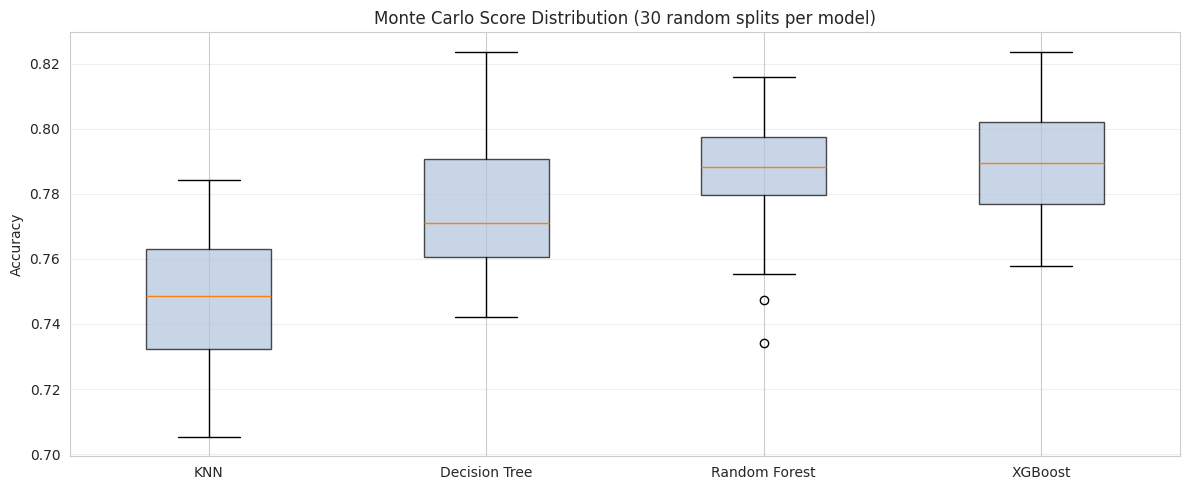

In [26]:
# Re-collect all MC scores into arrays for box plot
all_mc_scores = {
    'KNN'          : cross_val_score(knn_best, X, y,
                         cv=ShuffleSplit(N_MC_FINAL, test_size=0.25), scoring='accuracy', n_jobs=-1),
    'Decision Tree': cross_val_score(dt_best,  X, y,
                         cv=ShuffleSplit(N_MC_FINAL, test_size=0.25), scoring='accuracy', n_jobs=-1),
    'Random Forest': cross_val_score(rf_best,  X, y,
                         cv=ShuffleSplit(N_MC_FINAL, test_size=0.25), scoring='accuracy', n_jobs=-1),
    'XGBoost'      : cross_val_score(xgb_best, X, y,
                         cv=ShuffleSplit(N_MC_FINAL, test_size=0.25), scoring='accuracy', n_jobs=-1),
}

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(all_mc_scores.values(), labels=all_mc_scores.keys(), patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', alpha=0.7))
ax.set_ylabel('Accuracy')
ax.set_title(f'Monte Carlo Score Distribution ({N_MC_FINAL} random splits per model)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### 6.5 Feature Importance — Tree-Based Models

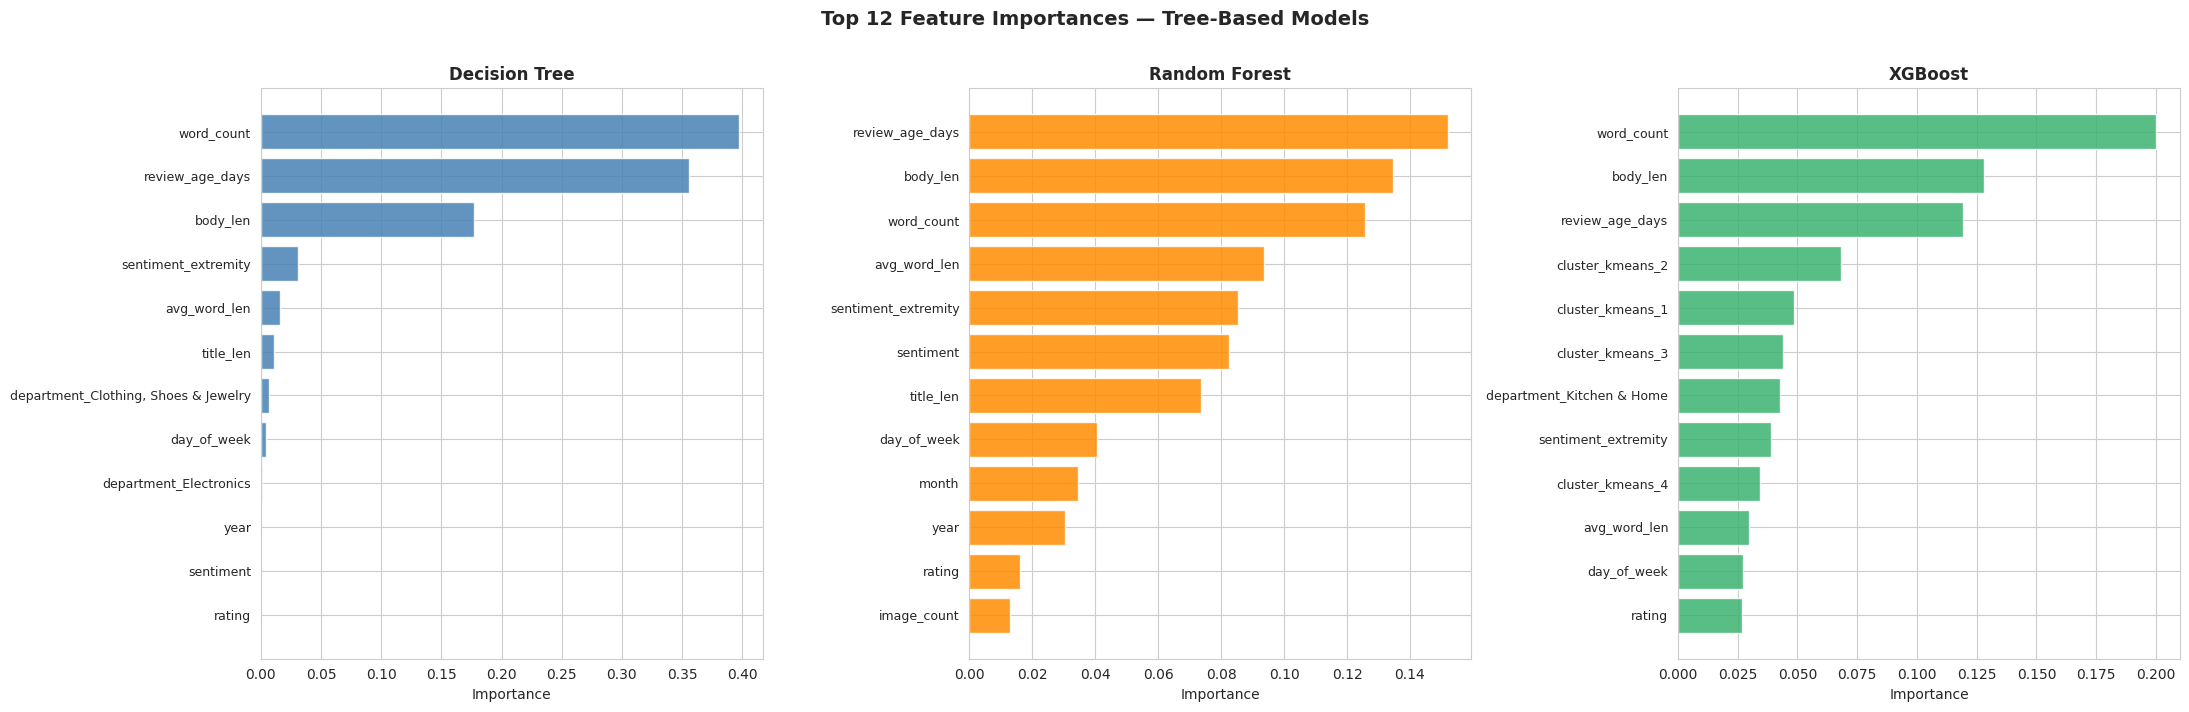

In [27]:
prep_fitted = dt_best.named_steps['preprocessor']
cat_feats   = list(prep_fitted.named_transformers_['cat']
                   .get_feature_names_out(categorical_cols))
all_feats   = numerical_cols + cat_feats

top_n = 12

def top_imp(importances, label, n=top_n):
    df_imp = pd.DataFrame({'feature': all_feats, 'importance': importances})
    return df_imp.sort_values('importance', ascending=False).head(n).assign(model=label)

combined = pd.concat([
    top_imp(dt_best.named_steps['dt'].feature_importances_,   'Decision Tree'),
    top_imp(rf_best.named_steps['rf'].feature_importances_,   'Random Forest'),
    top_imp(xgb_best.named_steps['xgb'].feature_importances_, 'XGBoost'),
])

palette = {'Decision Tree': 'steelblue',
           'Random Forest': 'darkorange',
           'XGBoost':       'mediumseagreen'}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, (model_name, grp) in zip(axes, combined.groupby('model', sort=False)):
    grp = grp.sort_values('importance')
    ax.barh(grp['feature'], grp['importance'],
            color=palette[model_name], alpha=0.85)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle(f'Top {top_n} Feature Importances — Tree-Based Models',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Conclusion

| Model | Key strength | Watch out for |
|---|---|---|
| **KNN** | Simple, no assumptions | Train=1.0 with distance weights is an artefact; use CV score |
| **Decision Tree** | Fully interpretable | Overfits without tight pruning |
| **Random Forest** | Robust, needs little tuning | Higher memory; moderate gap |
| **XGBoost** | Best CV score; built-in regularisation | More hyperparameters to tune |

**Best model is determined by Monte Carlo mean accuracy** (30 random splits) with CV score as tiebreaker — more reliable than a single fixed test split on 380 samples.

All models share the same `Pipeline` + `ColumnTransformer`, guaranteeing leak-proof preprocessing across all CV folds. `location` and `location_freq` were removed as exposure-bias proxies rather than genuine helpfulness signals.
